In [62]:
import torch

import ProcessOptimizer as op
from ProcessOptimizer.model_systems import gaussian_process_benchmark as gp_benchmark
from ProcessOptimizer import Optimizer

from ProcessOptimizer.learning import ExtraTreesRegressor

 # Single Task Case

In [37]:
lower_bound = -1.5
upper_bound = 1.5

opt = Optimizer([(lower_bound, upper_bound)], "GP", acq_optimizer="sampling")
gp1 = gp_benchmark.GPExperiment(lower_bound, upper_bound)
print('min: %s'%(gp1.min))

path = {}

for idx_ in range(50):
    next = opt.ask()
    f_val = gp1.score(next[0])
    opt.tell(next, f_val)
    path[idx_] = [next[0], f_val]
    
print(path[49])

min: -0.4447835683822632
[0.982471148835903, -0.44299399852752686]


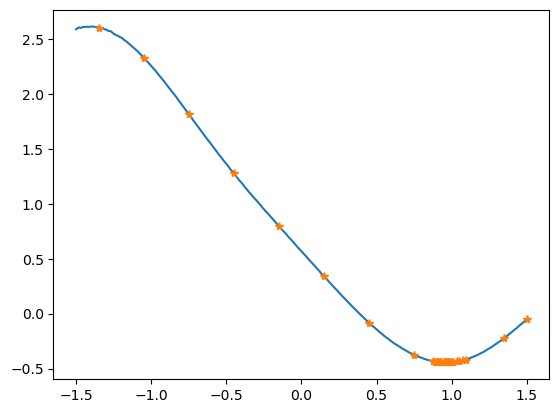

In [38]:
import matplotlib.pyplot as plt
plt.plot(gp1.domain, gp1.f_values);
plt.plot([val[0] for _, val in path.items()], [val[1] for _, val in path.items()], '*');

# 1D 4 Tasks Learner

In [40]:
gp2 = gp_benchmark.GPExperiment(-1.5, 1.5, 4, 1.5, 0.5)

idx, train_x, train_y = gp2.get_sample(10)

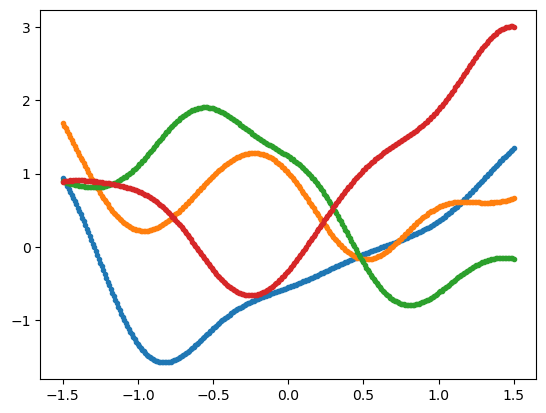

In [41]:
from matplotlib import pyplot as plt

plt.plot(gp2.domain, gp2.f_values, '.');

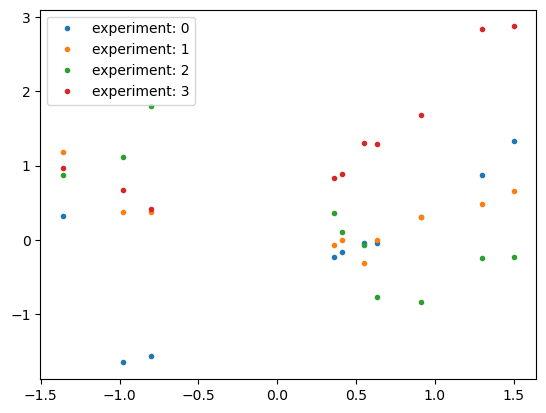

In [42]:
from matplotlib import pyplot as plt

for idx_ in range(train_y.shape[1]):
  plt.plot(train_x, train_y[:, idx_], '.', label='experiment: %s'%(idx_));

plt.legend();

In [50]:
from ProcessOptimizer.learning import GaussianProcessRegressor
from ProcessOptimizer.learning.gaussian_process import kernels

active_task_ = 1

kernel_ = kernels.ConstantKernel(constant_value=1.8)*kernels.RBF(length_scale=0.3)
gp = GaussianProcessRegressor(kernel=kernel_).fit(train_x.reshape(-1, 1), train_y[...,active_task_])

/Users/bromia/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [51]:
gp.get_params()

{'alpha': 1e-10,
 'copy_X_train': True,
 'kernel__k1': 1.34**2,
 'kernel__k2': RBF(length_scale=0.3),
 'kernel__k1__constant_value': 1.8,
 'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
 'kernel__k2__length_scale': 0.3,
 'kernel__k2__length_scale_bounds': (1e-05, 100000.0),
 'kernel': 1.34**2 * RBF(length_scale=0.3),
 'n_restarts_optimizer': 0,
 'noise': None,
 'noise_level_bounds': (1e-05, 100000.0),
 'normalize_y': False,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': None}

In [52]:
params = {
     'alpha': 1e-10,
     'copy_X_train': True,
     'kernel__k1': 1.34**2,
     'kernel__k2': kernels.RBF(length_scale=0.4),
     'kernel__k1__constant_value': 1.8,
     'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
     'kernel__k2__length_scale': 0.3,
     'kernel__k2__length_scale_bounds': (1e-05, 100000.0),
     'kernel': 1.34**2 * kernels.RBF(length_scale=0.3),
     'n_restarts_optimizer': 0,
     'noise': None,
     'noise_level_bounds': (1e-05, 100000.0),
     'normalize_y': False,
     'optimizer': 'fmin_l_bfgs_b',
     'random_state': None
}

In [53]:
gp.set_params(**params)

GaussianProcessRegressor(kernel=1.7956000000000003 * RBF(length_scale=0.4))

# Task Class and XPyriMentor Implementation

In [55]:
import ProcessOptimizer as op 
from ProcessOptimizer import XpyriMentor 

In [58]:
task_space = op.Space([[-1.5, 1.5], [0, 1, 2, 3, {active_task_}]])

In [59]:
director = XpyriMentor(task_space)
print(director)

XpyriMentor with a SequentialStrategizer suggestor


In [61]:
# samples points from the search space 
first_suggested_params = director.ask(5, active_task=True)

TypeError: XpyriMentor.ask() got an unexpected keyword argument 'active_task'

In [ ]:
first_suggested_params[0]

In [ ]:
first_suggested_params

In [ ]:
# evaluate points using oracle and pass them to suggestor

In [ ]:
import torch 
import numpy as np

train_x = torch.from_numpy(np.array(first_suggested_params, dtype=np.float32))
train_x[:, 0].unsqueeze(1), train_x[:, 1].unsqueeze(1)

In [ ]:

plt.plot(train_x[:, 0].unsqueeze(1), [gp2.score(itm_.item()) for itm_ in train_x[:, 0].unsqueeze(1)], '.');

In [ ]:
director.tell(train_x[:, 0].unsqueeze(1), [gp2.score(itm_.item()) for itm_ in train_x[:, 0].unsqueeze(1)])

In [ ]:
second_suggested_params = director.ask(4)
print(second_suggested_params)

In [ ]:
suggestor_definition = {
    "suggestor_name": "Sequential",
    "suggestors": [
        {"suggestor_budget": 7, "suggestor_name": "LHS"},
        {
            "suggestor_budget": 20,
            "suggestor_name": "Random",
            "suggestors": [
                {
                    "suggestor_usage_ratio": 80,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 10},
                },
                {
                    "suggestor_usage_ratio": 20,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 0.00001},
                },
            ],
        },
        {
            "suggestor_budget": float("inf"),
            "suggestor_name": "PO",
            "acq_func_kwargs": {"xi": 0.00001}
        },
    ]
}

director = XpyriMentor(task_space, suggestor_definition)
intial_suggestions = director.ask(5)
director.tell(intial_suggestions, [0.5, 0.6, -0.7, 0.8, 0.9])
print(director.ask(10))

In [ ]:
suggestor_definition = {
    "suggestor_name": "Sequential",
    "suggestors": [
        {"suggestor_budget": 7, "suggestor_name": "LHS"},
        {
            "suggestor_budget": 20,
            "suggestor_name": "Random",
            "suggestors": [
                {
                    "suggestor_usage_ratio": 80,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 10},
                },
                {
                    "suggestor_usage_ratio": 20,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 0.00001},
                },
            ],
        },
        {
            "suggestor_budget": float("inf"),
            "suggestor_name": "PO",
            "acq_func_kwargs": {"xi": 0.00001}
        },
    ]
}

In [ ]:
from ProcessOptimizer.XpyriMentor.suggestors import MTSuggestor

In [ ]:
suggestor = MTSuggestor([[-1.5, 1.5], [0, 1, 2, 3, {2}]], 1, 42)

In [ ]:
task_space

In [ ]:
task_space.__dict__

In [ ]:
objective_fcn =lambda tens_: [gp2.score(itm_.item()) for itm_ in tens_]
train_y = objective_fcn(train_x[:, 0].unsqueeze(1))

In [ ]:
director = XpyriMentor([[-1.5, 1.5], [0, 1, 2, 3, {2}]], suggestor)

In [ ]:
director.tell(train_x[:, 0].unsqueeze(1), train_y[:, 0].unsqueeze(1))

In [ ]:
director.tell(train_x[:, 0].unsqueeze(1), train_y[:, 0].unsqueeze(1))

In [ ]:
Xi = [torch.split(train_x, 1, 1)[0].squeeze().tolist(), torch.split(train_x, 1, 1)[1].squeeze().tolist()] 
Xi

In [ ]:
suggestor.initialise_model(torch.split(train_x, 1, 1)[0].squeeze().tolist(), )

In [ ]:
director.ask()

In [ ]:
type(director.Xi), type(director.yi)

In [ ]:
train_x[:, 0].unsqueeze(1).squeeze()

In [ ]:
train_y.split

In [ ]:
train_y[:, 0].squeeze().tolist()

In [ ]:
Xi, task_space.transform(Xi)

In [ ]:
task_space

In [ ]:
director.Xi[0].clone().detach()